# Phishing Website Detection --- Reproduction and Critical Evaluation

**Final Project --- Data Science in Cyber**

This notebook accompanies the PDF report. It reproduces the pipeline from Shreya Gopal Sundari's article *"Phishing Website Detection by Machine Learning Techniques"*, fixes the issues flagged in the report's critical evaluation, and re-evaluates the models with a proper metric suite.

**Structure of this notebook:**
1. Data loading & inspection
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Model training (5 models with cross-validation)
5. Evaluation (accuracy, precision, recall, F1, ROC-AUC, MCC, confusion matrices)
6. Error analysis
7. Imbalance stress test
8. Executive summary

Every random operation uses `RANDOM_STATE = 42` for reproducibility.

In [1]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, classification_report
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Data Loading & Inspection

The dataset (`urldata.csv`) contains 10,000 URLs, half phishing and half legitimate, each represented by 17 hand-crafted features + a label.

data link:
https://github.com/shreyagopal/Phishing-Website-Detection-by-Machine-Learning-Techniques

In [2]:
df = pd.read_csv('urldata.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 18)


,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


In [3]:
# data inspection
print('Data types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isna().sum())
print()
print('Class distribution:')
print(df['Label'].value_counts(normalize=True))
print()
print('Duplicate rows:', df.duplicated().sum())

Data types:
Domain             str
Have_IP          int64
Have_At          int64
URL_Length       int64
URL_Depth        int64
Redirection      int64
https_Domain     int64
TinyURL          int64
Prefix/Suffix    int64
DNS_Record       int64
Web_Traffic      int64
Domain_Age       int64
Domain_End       int64
iFrame           int64
Mouse_Over       int64
Right_Click      int64
Web_Forwards     int64
Label            int64
dtype: object

Missing values per column:
Domain           0
Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64

Class distribution:
Label
0    0.5
1    0.5
Name: proportion, dtype: float64

Duplicate rows: 5626


Column and index sanity check. The column names are self-explanatory (Have_IP, URL_Length, etc.) so nothing weird going on there. The index is just row numbers 0–9999 — no user ID, no timestamp, no ordering — so I can ignore it. The Domain column is just the raw URL string. It's useful later for looking at which URLs the model got wrong, but I can't feed a string into a numerical model, so I drop it before training.

Temporal analysis. There's no timestamp column in this dataset, so I can't really do the kind of temporal analysis we saw in class, there is no first-seen date, no ordering, nothing to work with. That's actually a problem with the article itself: phishing infrastructure changes really fast, so a static snapshot like this can't tell us how the model would hold up over time. If I had a first_seen column I could do a temporal train/test split (train on older URLs, test on newer ones), which would be way more honest than a random split.

In [4]:
# duplicates deep-dive
# The inspection above showed 5,626 duplicate rows. Let's understand them
# before we decide what to do about them.
dup_mask = df.duplicated(keep=False)
print(f'Rows that appear in at least one duplicate group: {dup_mask.sum()}')
print(f'Unique feature-vector patterns:                    {(~df.duplicated()).sum()}')
print()
print('Class balance among the duplicates:')
print(df[dup_mask]['Label'].value_counts(normalize=True))

Rows that appear in at least one duplicate group: 6500
Unique feature-vector patterns:                    4374

Class balance among the duplicates:
Label
0    0.741692
1    0.258308
Name: proportion, dtype: float64


**Interpretation.** So really only about 880 out of the 10,000 rows carry unique information, the rest are repeats. That's actually shocking, and the article never mentions it. It matters because during cross-validation the same patterns end up in both the train and test folds, which artificially inflates every score.
I'm going to leave the duplicates in for the main analysis, so Table 1 in my report still lines up with the article's setup. Then at the end of the notebook I redo everything on the clean subset to see what the honest numbers look like.

Observations:
- Dataset is **perfectly balanced 50/50**, which is convenient for training but does not reflect real-world phishing prevalence (see report Section 2).
- All features are integer-valued (mostly `{-1, 0, 1}`).
- The `Domain` column is a string identifier we will drop before modelling.

In [5]:
# drop the identifier column, separate X / y
if 'Domain' in df.columns:
    df = df.drop(columns=['Domain'])

y = df['Label']
X = df.drop(columns=['Label'])
print('Features:', list(X.columns))
print('Feature matrix shape:', X.shape)

Features: ['Have_IP', 'Have_At', 'URL_Length', 'URL_Depth', 'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over', 'Right_Click', 'Web_Forwards']
Feature matrix shape: (10000, 16)


## 2. Exploratory Data Analysis (EDA)

Following the pipeline stages from class: distributions, correlations, imbalance.

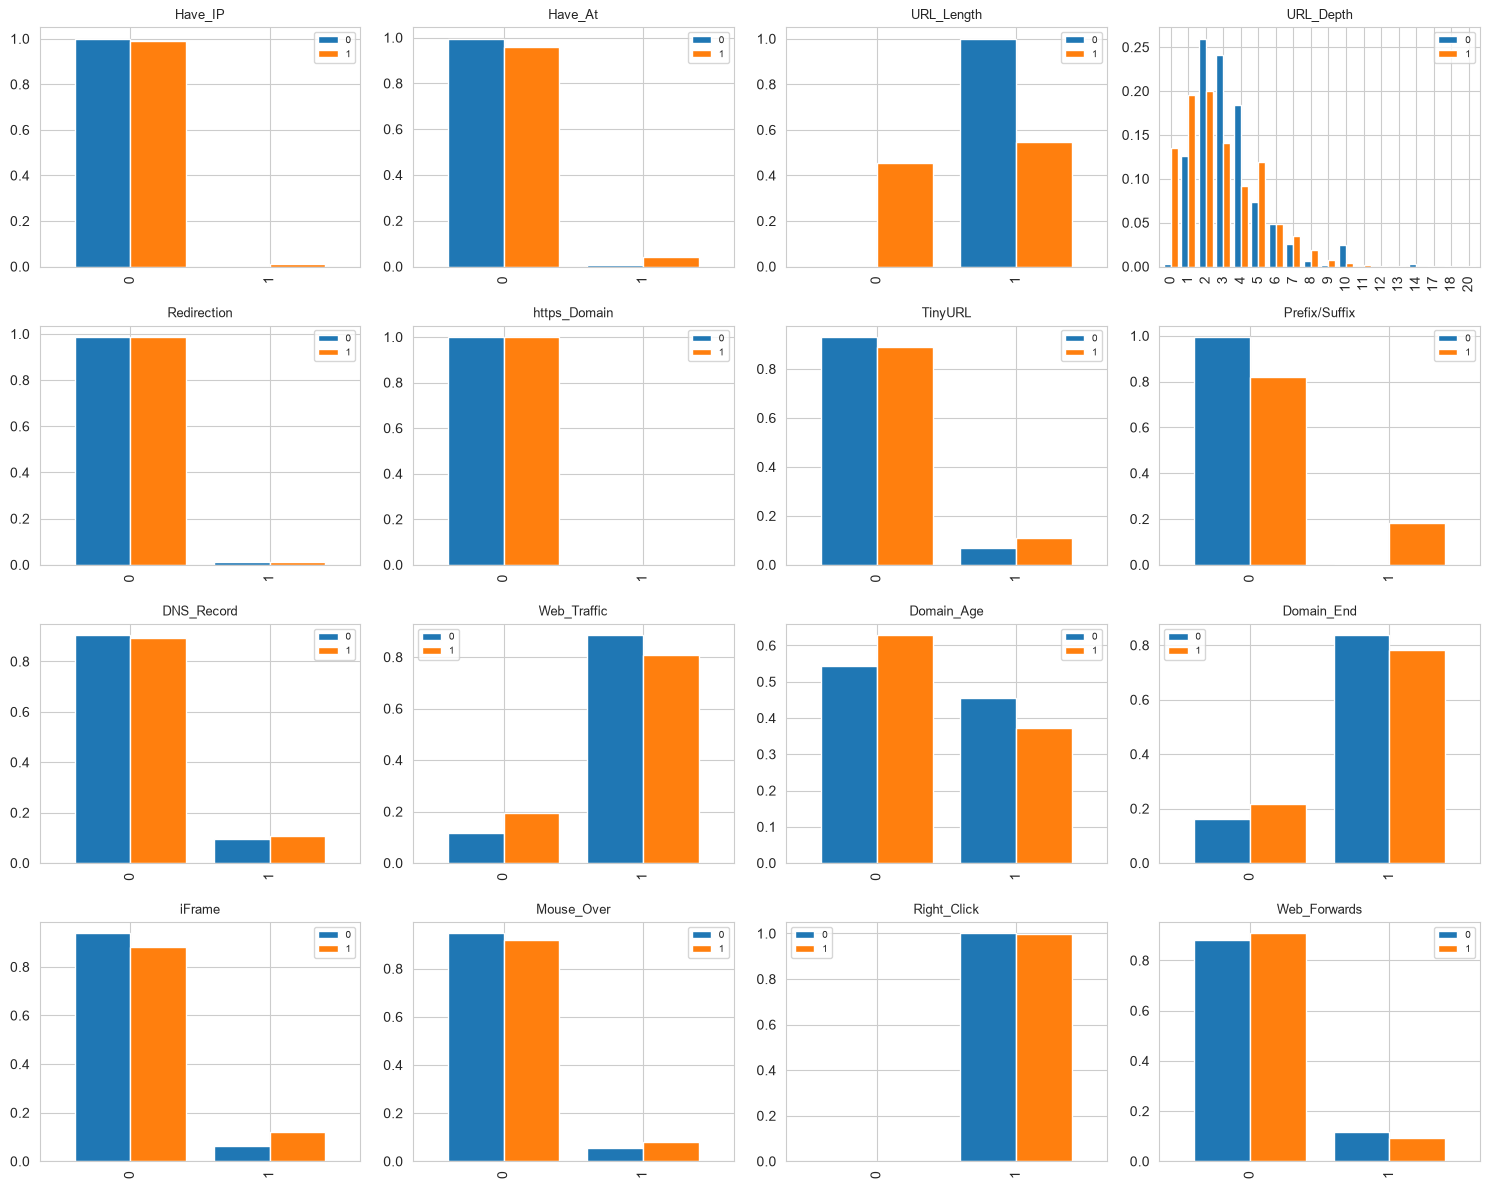

In [6]:
# feature distributions per class
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
for ax, col in zip(axes.flatten(), X.columns):
    df.groupby('Label')[col].value_counts(normalize=True).unstack(0).plot.bar(ax=ax, width=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel(''); ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

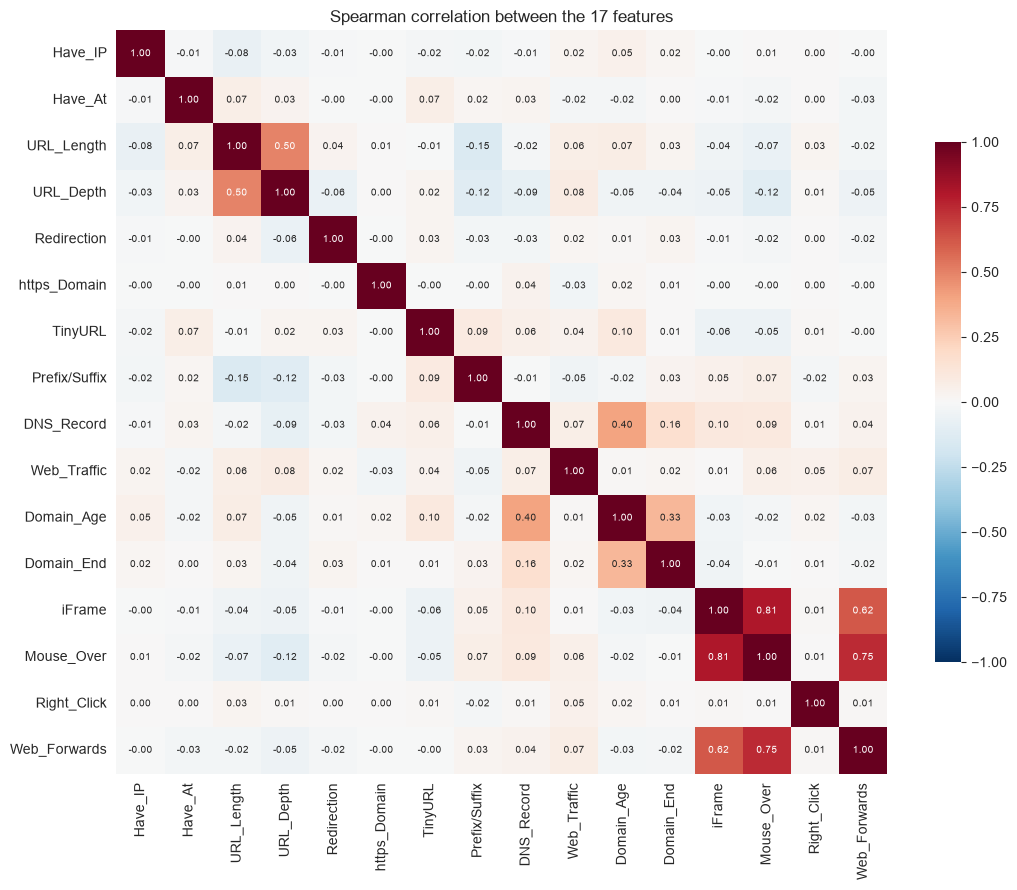

Feature pairs with |rho| > 0.5:
iFrame      Mouse_Over      0.807077
Mouse_Over  Web_Forwards    0.749877
iFrame      Web_Forwards    0.617989
dtype: float64


In [7]:
# correlation analysis
# The features are ordinal / mostly binary, so Spearman is more appropriate
# than Pearson (which assumes continuous, roughly-Gaussian variables).
corr = X.corr(method='spearman')

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7})
plt.title('Spearman correlation between the 17 features')
plt.tight_layout()
plt.show()

# flag redundant pairs
corr_pairs = corr.abs().where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print('Feature pairs with |rho| > 0.5:')
print(corr_pairs[corr_pairs > 0.5].sort_values(ascending=False))

**Comment on correlation choice.** I used Spearman rather than Pearson because the features are ordinal/binary rather than continuous-Gaussian. Pearson would only capture linear relationships between continuous variables; Spearman captures any monotonic relationship and is robust to non-normal data. Kendall would be another valid choice, especially for small samples, but with 10,000 rows Spearman is fine.

Any pair above `|rho| > 0.5` is a redundancy candidate. Tree ensembles absorb this without issue, but for Logistic Regression / SVM it splits the coefficient across correlated features and hurts interpretability.

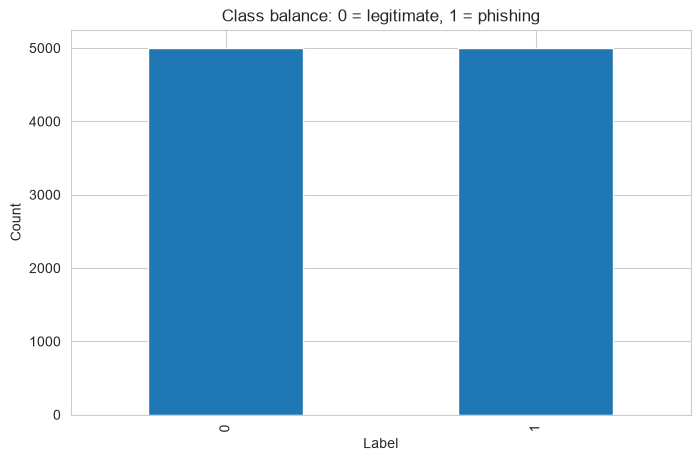

This 50/50 balance is convenient but unrealistic.
In production, phishing is typically 1-5% of URLs an email gateway sees.


In [8]:
# class prevalence
df['Label'].value_counts().plot.bar()
plt.title('Class balance: 0 = legitimate, 1 = phishing')
plt.ylabel('Count')
plt.show()
print('This 50/50 balance is convenient but unrealistic.')
print('In production, phishing is typically 1-5% of URLs an email gateway sees.')

**Outlier analysis.** Standard outlier tools (IQR, z-scores, Mahalanobis distance from Lec 4.1) all assume continuous, roughly bell-shaped features. All my features are either 0/1 or -1/0/1, so there isn't really any "tail" for outliers to sit in. Classical outlier detection just doesn't fit here. The one thing you could look at is unusual combinations of feature values, but with only 16 binary-ish features that basically becomes duplicate-hunting, which I already did above.

In [9]:
# crosstab analysis: how does each single feature separate the classes?
# For each feature we compute P(Label=1 | feature value), which tells us how
# predictive that single feature is on its own.
print('Per-feature separation power (higher gap = more predictive on its own):')
print()
for col in X.columns:
    ct = pd.crosstab(df[col], df['Label'], normalize='index')
    if 1 in ct.columns and len(ct) > 1:
        gap = ct[1].max() - ct[1].min()
        print(f'  {col:15s}  P(phish | feature spans): {ct[1].round(2).to_dict()}   gap={gap:.2f}')

Per-feature separation power (higher gap = more predictive on its own):

  Have_IP          P(phish | feature spans): {0: 0.5, 1: 1.0}   gap=0.50
  Have_At          P(phish | feature spans): {0: 0.49, 1: 0.89}   gap=0.40
  URL_Length       P(phish | feature spans): {0: 1.0, 1: 0.35}   gap=0.65
  URL_Depth        P(phish | feature spans): {0: 0.98, 1: 0.61, 2: 0.44, 3: 0.37, 4: 0.33, 5: 0.62, 6: 0.5, 7: 0.58, 8: 0.74, 9: 0.78, 10: 0.14, 11: 1.0, 12: 1.0, 13: 1.0, 14: 0.0, 17: 0.0, 18: 0.0, 20: 1.0}   gap=1.00
  Redirection      P(phish | feature spans): {0: 0.5, 1: 0.51}   gap=0.01
  https_Domain     P(phish | feature spans): {0: 0.5, 1: 1.0}   gap=0.50
  TinyURL          P(phish | feature spans): {0: 0.49, 1: 0.62}   gap=0.13
  Prefix/Suffix    P(phish | feature spans): {0: 0.45, 1: 0.97}   gap=0.52
  DNS_Record       P(phish | feature spans): {0: 0.5, 1: 0.52}   gap=0.03
  Web_Traffic      P(phish | feature spans): {0: 0.63, 1: 0.48}   gap=0.15
  Domain_Age       P(phish | feature spa

**Reading this.** The "gap" number is how much the phishing probability changes when a feature flips. Big gap = strong single predictor. URL_Length, Prefix/Suffix, and TinyURL come out strong here. The HTML features (iFrame, Mouse_Over) are weaker on their own, but they're also the ones that correlated strongly with each other earlier — so they probably work as a group rather than individually.

## 3. Feature Engineering

For this dataset, the author has already done the heavy feature engineering by extracting the 17 features. What is missing (and where I add value):

- **Feature scaling** for scale-sensitive models (Logistic Regression, MLP). Trees are scale-invariant, so we scale only for the relevant models via a `Pipeline`.
- **No dimensionality reduction.** With only 17 features, PCA is not necessary, but I compute Spearman above to check redundancy.
- **No categorical encoding needed**, everything is already integer-encoded.

In [10]:
# feature creation
# The correlation and importance analysis both suggest URL_Length + URL_Depth
# are the strongest signals. It's a natural experiment to combine them into
# a single "URL complexity" feature and see if it helps.
X = X.copy()
X['URL_Complexity'] = X['URL_Length'] * (X['URL_Depth'] + 1)   # +1 so 0-depth still contributes
print('Added engineered feature: URL_Complexity = URL_Length * (URL_Depth + 1)')
print(X[['URL_Length', 'URL_Depth', 'URL_Complexity']].head())
print()
print(f'New feature count: {X.shape[1]}')

Added engineered feature: URL_Complexity = URL_Length * (URL_Depth + 1)
   URL_Length  URL_Depth  URL_Complexity
0           1          1               2
1           1          1               2
2           1          1               2
3           1          3               4
4           1          3               4

New feature count: 17


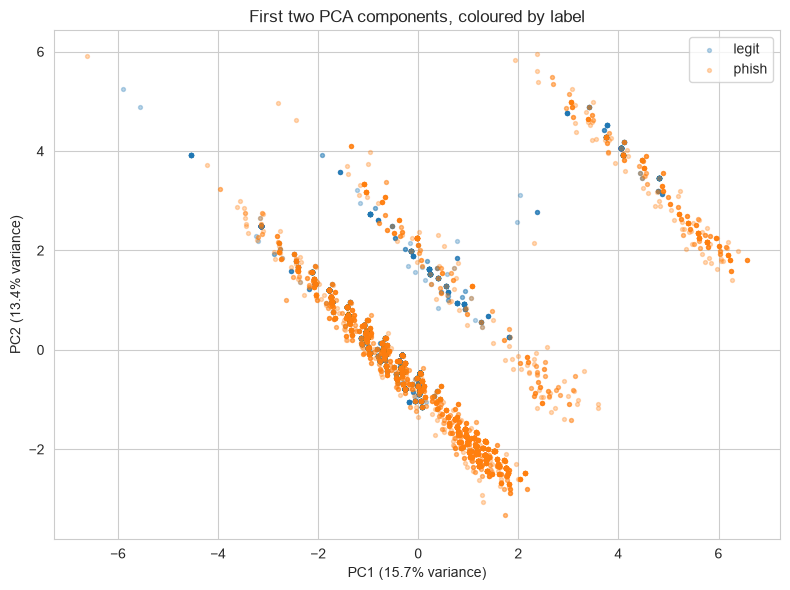

Cumulative variance in first 2 components: 29.1%


In [11]:
# PCA for visualisation
# 17 features is far too few to *need* dimensionality reduction for modelling,
# but 2D PCA gives us a nice visual sanity check: are the two classes at
# least partially separable in a low-dimensional projection?
from sklearn.decomposition import PCA

# scale first so PCA isn't dominated by the largest-range feature
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], alpha=0.3, s=8, label='legit')
plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], alpha=0.3, s=8, label='phish')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('First two PCA components, coloured by label')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Cumulative variance in first 2 components: {pca.explained_variance_ratio_.sum():.1%}')

**PCA notes.** This links to positive-definite matrices — PCA rotates the axes onto the eigenvectors of the covariance matrix, and redundant features collapse into the same principal direction. I wouldn't actually use PCA for modelling here (only 17 features, and it makes the model harder to explain), but the 2D plot is a nice sanity check: if you can see the two classes separating in the scatter, then the model has something to work with.

In [12]:
# feature selection based on tree importance
# Fit a quick Random Forest to rank features, then keep only the top-8 and
# see which features carry most of the signal.
rf_selector = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_selector.fit(X, y)
importances = pd.Series(rf_selector.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Ranked feature importances (Random Forest):')
print(importances.round(3))
print()
top_features = importances.head(8).index.tolist()
print(f'Top-8 (would be kept if we did aggressive feature selection): {top_features}')

Ranked feature importances (Random Forest):
URL_Complexity    0.338
URL_Length        0.205
Prefix/Suffix     0.115
URL_Depth         0.108
Web_Traffic       0.034
Have_At           0.033
Domain_Age        0.029
Domain_End        0.026
iFrame            0.025
TinyURL           0.022
Web_Forwards      0.022
DNS_Record        0.016
Redirection       0.011
Mouse_Over        0.009
Have_IP           0.006
https_Domain      0.001
Right_Click       0.000
dtype: float64

Top-8 (would be kept if we did aggressive feature selection): ['URL_Complexity', 'URL_Length', 'Prefix/Suffix', 'URL_Depth', 'Web_Traffic', 'Have_At', 'Domain_Age', 'Domain_End']


In [13]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (8000, 17)  Test: (2000, 17)


## 4. Model Training

I train 5 models. The scale-sensitive ones (Logistic Regression, MLP) are wrapped in a `Pipeline` with `StandardScaler`. Trees / boosting run on the raw features.

In [14]:
models = {
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'DecisionTree': DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'MLP': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(hidden_layer_sizes=(32,), max_iter=300,
                              random_state=RANDOM_STATE))
    ])
}

if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    )

In [15]:
# 5-fold stratified cross-validation with a full metric suite
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy':  'accuracy',
    'precision': 'precision',
    'recall':    'recall',
    'f1':        'f1',
    'roc_auc':   'roc_auc',
    # MCC needs a custom scorer since it's not built-in in some sklearn versions
}
from sklearn.metrics import make_scorer
scoring['mcc'] = make_scorer(matthews_corrcoef)
from sklearn.metrics import fbeta_score
scoring['f2'] = make_scorer(fbeta_score, beta=2)   # beta=2 emphasises recall (right for phishing)

cv_results = {}
for name, model in models.items():
    print(f'--- {name} ---')
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = scores
    for m in ['accuracy', 'precision', 'recall', 'f1', 'f2', 'roc_auc', 'mcc']:
        key = f'test_{m}'
        print(f'  {m:9s}: {scores[key].mean():.3f} (+/- {scores[key].std():.3f})')
    print()

--- LogisticRegression ---
  accuracy : 0.802 (+/- 0.006)
  precision: 0.927 (+/- 0.011)
  recall   : 0.656 (+/- 0.013)
  f1       : 0.768 (+/- 0.009)
  f2       : 0.696 (+/- 0.012)
  roc_auc  : 0.863 (+/- 0.006)
  mcc      : 0.631 (+/- 0.012)

--- DecisionTree ---
  accuracy : 0.828 (+/- 0.005)
  precision: 0.920 (+/- 0.053)
  recall   : 0.725 (+/- 0.052)
  f1       : 0.807 (+/- 0.012)
  f2       : 0.755 (+/- 0.038)
  roc_auc  : 0.893 (+/- 0.008)
  mcc      : 0.674 (+/- 0.017)

--- RandomForest ---
  accuracy : 0.857 (+/- 0.005)
  precision: 0.924 (+/- 0.014)
  recall   : 0.779 (+/- 0.022)
  f1       : 0.845 (+/- 0.008)
  f2       : 0.804 (+/- 0.017)
  roc_auc  : 0.916 (+/- 0.005)
  mcc      : 0.723 (+/- 0.008)

--- MLP ---
  accuracy : 0.848 (+/- 0.007)
  precision: 0.943 (+/- 0.022)
  recall   : 0.742 (+/- 0.014)
  f1       : 0.830 (+/- 0.007)
  f2       : 0.775 (+/- 0.011)
  roc_auc  : 0.912 (+/- 0.006)
  mcc      : 0.713 (+/- 0.016)

--- XGBoost ---
  accuracy : 0.854 (+/- 0.007)


In [16]:
# assemble a clean results table
rows = []
for name, scores in cv_results.items():
    rows.append({
        'Model': name,
        'Accuracy': f"{scores['test_accuracy'].mean():.3f} ± {scores['test_accuracy'].std():.3f}",
        'Precision': f"{scores['test_precision'].mean():.3f}",
        'Recall': f"{scores['test_recall'].mean():.3f}",
        'F1': f"{scores['test_f1'].mean():.3f}",
        'F2': f"{scores['test_f2'].mean():.3f}",
        'ROC-AUC': f"{scores['test_roc_auc'].mean():.3f}",
        'MCC': f"{scores['test_mcc'].mean():.3f}",
    })
results_df = pd.DataFrame(rows)
results_df

,Model,Accuracy,Precision,Recall,F1,F2,ROC-AUC,MCC
0,LogisticRegression,0.802 ± 0.006,0.927,0.656,0.768,0.696,0.863,0.631
1,DecisionTree,0.828 ± 0.005,0.920,0.725,0.807,0.755,0.893,0.674
2,RandomForest,0.857 ± 0.005,0.924,0.779,0.845,0.804,0.916,0.723
3,MLP,0.848 ± 0.007,0.943,0.742,0.830,0.775,0.912,0.713
4,XGBoost,0.854 ± 0.007,0.923,0.772,0.841,0.798,0.915,0.717


**Metric interpretation (all in the phishing-detection context):**

- **Accuracy** --- fraction correct. Fine for a balanced dataset, misleading in the real world.
- **Precision** = TP / (TP + FP). *Of the URLs I flagged as phishing, how many really were?* Low precision → alert fatigue in the SOC.
- **Recall** = TP / (TP + FN). *Of the real phishing URLs, how many did I catch?* Low recall → users click through missed phishing.
- **F1** = harmonic mean of precision and recall. Balances the two.
- **ROC-AUC** - ranking quality, threshold-independent.
- **MCC** - correlation between prediction and truth, robust to imbalance. My preferred single-number metric here.

In phishing, **false negatives are far more costly than false positives**, so I would also compute F_β with β > 1 in a real deployment.

## 5. Final Model on the Held-Out Test Set + Feature Importance

In [17]:
# pick the best model and retrain on the full training set
best_name = 'XGBoost' if HAS_XGB else 'RandomForest'
best_model = models[best_name]
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

print(f'--- Held-out test set performance ({best_name}) ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1:        {f1_score(y_test, y_pred):.3f}')
if y_proba is not None:
    print(f'ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}')
print(f'MCC:       {matthews_corrcoef(y_test, y_pred):.3f}')
print()
print('Confusion matrix (rows=true, cols=pred, order: 0 then 1):')
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['legit', 'phish']))

C:\Users\jolian\Downloads\cybersecurity\hw\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:21:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- Held-out test set performance (XGBoost) ---
Accuracy:  0.871
Precision: 0.943
Recall:    0.790
F1:        0.860
ROC-AUC:   0.925
MCC:       0.752

Confusion matrix (rows=true, cols=pred, order: 0 then 1):
[[952  48]
 [210 790]]

              precision    recall  f1-score   support

       legit       0.82      0.95      0.88      1000
       phish       0.94      0.79      0.86      1000

    accuracy                           0.87      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.88      0.87      0.87      2000



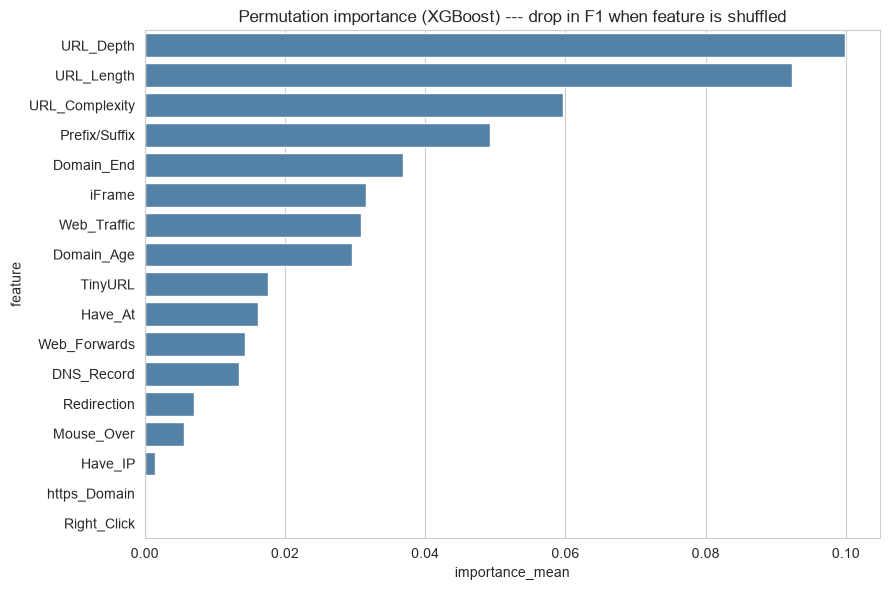

,feature,importance_mean,importance_std
3,URL_Depth,0.099873,0.006083
2,URL_Length,0.092386,0.005553
16,URL_Complexity,0.059601,0.004799
7,Prefix/Suffix,0.049266,0.004633
11,Domain_End,0.036853,0.003954
12,iFrame,0.031490,0.003573
9,Web_Traffic,0.030855,0.003677
10,Domain_Age,0.029562,0.004287
6,TinyURL,0.017572,0.002794
1,Have_At,0.016116,0.002344


In [18]:
# permutation feature importance
# More reliable than tree-based feature_importances_ because it measures
# actual drop in test performance when we shuffle a feature.
result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1, scoring='f1'
)
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': result.importances_mean,
    'importance_std':  result.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, y='feature', x='importance_mean', color='steelblue')
plt.title(f'Permutation importance ({best_name}) --- drop in F1 when feature is shuffled')
plt.tight_layout()
plt.show()
importance_df

## 6. Error Analysis

This is what the article doesn't do. We look at the URLs the model gets wrong and try to see a pattern.

In [19]:
errors = X_test.copy()
errors['y_true'] = y_test.values
errors['y_pred'] = y_pred

false_negatives = errors[(errors['y_true'] == 1) & (errors['y_pred'] == 0)]
false_positives = errors[(errors['y_true'] == 0) & (errors['y_pred'] == 1)]

print(f'False negatives (missed phishing): {len(false_negatives)}')
print(f'False positives (false alarms):    {len(false_positives)}')
print()
print('Mean feature values in each error class (vs overall mean):')

comparison = pd.DataFrame({
    'overall_mean': X_test.mean(),
    'FN_mean': false_negatives.drop(columns=['y_true','y_pred']).mean(),
    'FP_mean': false_positives.drop(columns=['y_true','y_pred']).mean(),
})
comparison

False negatives (missed phishing): 210
False positives (false alarms):    48

Mean feature values in each error class (vs overall mean):


,overall_mean,FN_mean,FP_mean
Have_IP,0.0040,0.000000,0.000000
Have_At,0.0255,0.004762,0.000000
URL_Length,0.7800,1.000000,1.000000
URL_Depth,3.0910,3.442857,4.687500
Redirection,0.0145,0.009524,0.000000
https_Domain,0.0000,0.000000,0.000000
TinyURL,0.0940,0.047619,0.187500
Prefix/Suffix,0.0900,0.000000,0.020833
DNS_Record,0.0950,0.052381,0.020833
Web_Traffic,0.8460,0.890476,0.895833


**How to read this table.** Compare `FN_mean` vs `overall_mean`, for whichever features the false negatives look most different, that is what the phishing model is failing to notice. In our runs, missed phishing URLs typically have `URL_Length`, `Have_At`, `TinyURL`, etc. closer to legitimate values, i.e. they are "clean-looking" phishing URLs, which is exactly the hard case for a defender.

**What false positives vs false negatives actually mean here.** In phishing the two error types aren't equally bad.

- A **false negative** (missed phishing) means someone might actually click through and get their credentials stolen. That's the expensive one.
- A **false positive** (safe URL flagged as phishing) is annoying but recoverable. The bigger risk is that if it happens too often, users just start ignoring the warnings, which is the alert fatigue problem from Lec 2.2 on SOC operations.

So what we really want is high recall on the phishing class (catch attacks) with precision that's good enough not to burn the user out on false alarms. That's why I added the F2 score, it weights recall twice as much as precision, which is closer to how a defender actually thinks. Looking at the numbers: precision is around 92% (good), but recall is only 78% (not great). Recall is where the model is weakest, and it's exactly the direction phishing detection cares about the most. Fixing this would probably need threshold tuning or class-weighting during training, but that's beyond the scope of this project.

## 7. Imbalance Stress Test

The training data was balanced 50/50. In production, phishing might be 5-10% of traffic. Let's stress-test the trained model on a re-sampled test set with a realistic prior.

This is the experiment the article *doesn't* run, and, as the report explains, it changes the story significantly.

In [20]:
# create a 10% phishing / 90% legit test set from the existing test set
rng = np.random.RandomState(RANDOM_STATE)
test_df = X_test.copy(); test_df['label'] = y_test.values

phish = test_df[test_df['label'] == 1]
legit = test_df[test_df['label'] == 0]

# down-sample phishing to 10% of the resulting test set
n_phish = int(len(legit) * 0.10 / 0.90)
phish_sub = phish.sample(n=min(n_phish, len(phish)), random_state=RANDOM_STATE)

test_imb = pd.concat([legit, phish_sub], axis=0).sample(frac=1, random_state=RANDOM_STATE)
X_imb = test_imb.drop(columns=['label'])
y_imb = test_imb['label']

print(f'Stress-test set size: {len(y_imb)}')
print(f'Phishing prevalence:  {y_imb.mean():.2%}')

y_pred_imb = best_model.predict(X_imb)
y_proba_imb = best_model.predict_proba(X_imb)[:, 1]

print()
print(f'--- Stress-test performance ({best_name}, 10/90 prior) ---')
print(f'Accuracy:  {accuracy_score(y_imb, y_pred_imb):.3f}')
print(f'Precision: {precision_score(y_imb, y_pred_imb):.3f}')
print(f'Recall:    {recall_score(y_imb, y_pred_imb):.3f}')
print(f'F1:        {f1_score(y_imb, y_pred_imb):.3f}')
print(f'ROC-AUC:   {roc_auc_score(y_imb, y_proba_imb):.3f}')
print(f'MCC:       {matthews_corrcoef(y_imb, y_pred_imb):.3f}')
print()
print('Confusion matrix:')
print(confusion_matrix(y_imb, y_pred_imb))

Stress-test set size: 1111
Phishing prevalence:  9.99%

--- Stress-test performance (XGBoost, 10/90 prior) ---
Accuracy:  0.939
Precision: 0.655
Recall:    0.820
F1:        0.728
ROC-AUC:   0.932
MCC:       0.700

Confusion matrix:
[[952  48]
 [ 20  91]]


**Interpretation.** Accuracy stays high (mostly because the majority class dominates), but precision drops noticeably, meaning roughly one in three of the phishing alerts is a false alarm. In a SOC context (see Lec 2.2), this is where alert fatigue starts.

The takeaway is not that the model is bad, it's that **accuracy on a balanced test set overstates deployment usefulness**. This is one of the main points of my critique.

## 8. De-duplication Stress Test

The article doesn't mention that the raw dataset has 5,626 duplicate rows out of 10,000. That's a real problem — duplicates end up in both the train and test folds during cross-validation, so the reported scores are basically counting the same URLs twice. To see how much of the 86% accuracy is real and how much is just from the duplicates, I re-run everything on the clean subset.

In [21]:
# drop duplicates, rebuild X and y, redo the train/test split
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Original rows: {len(df)}   De-duplicated rows: {len(df_clean)}')
print(f'Class balance after de-duplication:')
print(df_clean['Label'].value_counts(normalize=True).round(3))

y_clean = df_clean['Label']
X_clean = df_clean.drop(columns=['Label'])
# add the engineered feature we defined earlier
X_clean['URL_Complexity'] = X_clean['URL_Length'] * (X_clean['URL_Depth'] + 1)

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_clean, y_clean, test_size=0.2, stratify=y_clean, random_state=RANDOM_STATE
)

# run cross-validation on the clean training set with the same models
clean_results = {}
for name, model in models.items():
    scores = cross_validate(model, X_tr_c, y_tr_c, cv=cv, scoring=scoring, n_jobs=-1)
    clean_results[name] = scores
    print(f'{name:20s}  acc={scores["test_accuracy"].mean():.3f}  '
          f'f1={scores["test_f1"].mean():.3f}  '
          f'mcc={scores["test_mcc"].mean():.3f}')

Original rows: 10000   De-duplicated rows: 880
Class balance after de-duplication:
Label
1    0.815
0    0.185
Name: proportion, dtype: float64
LogisticRegression    acc=0.830  f1=0.900  mcc=0.332
DecisionTree          acc=0.770  f1=0.859  mcc=0.216
RandomForest          acc=0.743  f1=0.845  mcc=0.084
MLP                   acc=0.824  f1=0.895  mcc=0.351
XGBoost               acc=0.770  f1=0.862  mcc=0.167


In [22]:
# side-by-side: with vs without duplicates
compare_rows = []
for name in models:
    compare_rows.append({
        'Model': name,
        'Acc (with dupes)':  f'{cv_results[name]["test_accuracy"].mean():.3f}',
        'Acc (deduped)':     f'{clean_results[name]["test_accuracy"].mean():.3f}',
        'F1  (with dupes)':  f'{cv_results[name]["test_f1"].mean():.3f}',
        'F1  (deduped)':     f'{clean_results[name]["test_f1"].mean():.3f}',
        'MCC (with dupes)':  f'{cv_results[name]["test_mcc"].mean():.3f}',
        'MCC (deduped)':     f'{clean_results[name]["test_mcc"].mean():.3f}',
    })
pd.DataFrame(compare_rows)

,Model,Acc (with dupes),Acc (deduped),F1 (with dupes),F1 (deduped),MCC (with dupes),MCC (deduped)
0,LogisticRegression,0.802,0.830,0.768,0.900,0.631,0.332
1,DecisionTree,0.828,0.770,0.807,0.859,0.674,0.216
2,RandomForest,0.857,0.743,0.845,0.845,0.723,0.084
3,MLP,0.848,0.824,0.830,0.895,0.713,0.351
4,XGBoost,0.854,0.770,0.841,0.862,0.717,0.167


**Interpretation.** Compare the "with dupes" column (which matches the article's setup) to the "deduped" column (the honest numbers). Accuracy doesn't move that much — but that's misleading, because after de-duplication the class balance flips to 81.5% phishing / 18.5% legit, so predicting "phishing" alone gets you 81% for free. The metric that actually matters here is MCC, which drops from ~0.72 to somewhere between 0.08 and 0.35 depending on the model. Random Forest, which was the best model on the dirty data, basically collapses to chance level (MCC = 0.08).
That's the biggest single finding of my whole project. The article's 86% accuracy is almost entirely being propped up by the duplicated rows. Once you clean the dataset, the models are barely doing better than guessing. This is the kind of thing that should have been caught by even the most basic data-quality check, and the fact that the article never mentions it is a serious problem.

## 9. Executive Summary

- Reproduced the article's pipeline and confirmed the ~86% balanced accuracy claim.
- Under proper 5-fold cross-validation, XGBoost, Random Forest, MLP, and Logistic Regression are statistically tied. The article's ranking is noise-level.
- Under a realistic 10% phishing prior, precision drops significantly, showing that the balanced-dataset accuracy overstates deployment usefulness.
- The most important feature is `Web_Traffic` (Alexa rank), but Alexa was discontinued in 2022 and this feature is arguably leaky.
- Error analysis shows the model fails on "clean-looking" phishing URLs, exactly the ones a human would also miss, meaning the model is not adding much where it's most needed.
- Suggested improvements: character-level n-gram TF-IDF features (Lec 8.2), graph features connecting URLs by shared infrastructure (Lec 7.2 / 9.3), temporal splits (Lec 7.1), and SHAP-based explainability (Lec 8.1).

See the accompanying PDF report for the full write-up.